In [2]:
import pandas as pd
import os.path as op
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az

bids_folder = '/Users/mrenke/data/ds-stressrisk'
plot_folder_path = '/Users/mrenke/Desktop/StressRisk/figures/plots/fig_3'

sns.set_context('talk')


In [3]:
model_n = 6

#risk_preferences = pd.read_csv(op.join(bids_folder, 'derivatives', 'cogmodels', 'simple_risk_preference.tsv'), index_col=[0, 1], sep='\t')
sns.set_theme('paper', 'white', font='helvetica', font_scale=1.25, palette='tab10')

colors = {'risk-neutral':'k', 'risk-seeking':sns.color_palette('Spectral', 5)[0], 
          'risk-averse':sns.color_palette('Spectral', 5)[-1]}

In [4]:
print(*list(range(23,43)), sep=',')

23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42


In [5]:
idata = az.from_netcdf(op.join(bids_folder, 'derivatives', 'cogmodels', f'model-{model_n}_trace.netcdf'))

### Evidence SD

In [6]:
from bauer.utils.math import softplus_np

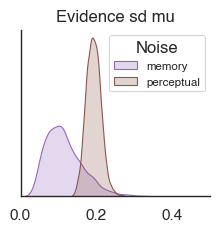

In [16]:
evidence_sd = pd.concat((idata.posterior['memory_noise_sd_mu'].to_dataframe(), (idata.posterior['perceptual_noise_sd_mu'].to_dataframe())), axis=1)
evidence_sd.columns.name = 'parameter'
evidence_sd.index = evidence_sd.index.set_names(['chain','draw','regressor']) # get handel on regressors #'subject',
evidence_sd = evidence_sd.stack().to_frame('value')
evidence_sd['Noise'] = evidence_sd.index.get_level_values('parameter').map({'memory_noise_sd_mu':'memory', 'perceptual_noise_sd_mu':'perceptual'})
evidence_sd['value_softpl'] = softplus_np(evidence_sd['value'])


fac = sns.FacetGrid(evidence_sd.xs('Intercept', 0,'regressor').reset_index(), hue='Noise', palette=sns.color_palette()[4:], aspect=1.1, height=2.5)
fac.map(sns.kdeplot, 'value_softpl', fill=True)
fac.set(xlabel=None, ylabel=None, yticks=[])
plt.title('Evidence sd mu')
# fac.add_legend()
plt.legend(title='Noise',loc='upper right',fontsize='x-small')
plt.xlim([0,0.5])
plt.savefig(op.join(plot_folder_path, 'NLC_model-6_evidence_sd.pdf'), bbox_inches='tight')

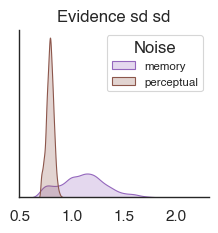

In [15]:
evidence_sd = pd.concat((idata.posterior['memory_noise_sd_sd'].to_dataframe(), (idata.posterior['perceptual_noise_sd_sd'].to_dataframe())), axis=1)
evidence_sd.columns.name = 'parameter'
evidence_sd.index = evidence_sd.index.set_names(['chain','draw','regressor']) # get handel on regressors #'subject',
evidence_sd = evidence_sd.stack().to_frame('value')
evidence_sd['Noise'] = evidence_sd.index.get_level_values('parameter').map({'memory_noise_sd_sd':'memory', 'perceptual_noise_sd_sd':'perceptual'})
evidence_sd['value_softpl'] = softplus_np(evidence_sd['value'])


fac = sns.FacetGrid(evidence_sd.xs('Intercept', 0,'regressor').reset_index(), hue='Noise', palette=sns.color_palette()[4:], aspect=1.1, height=2.5)
fac.map(sns.kdeplot, 'value_softpl', fill=True)
fac.set(xlabel=None, ylabel=None, yticks=[])
plt.title('Evidence sd sd')
# fac.add_legend()
plt.legend(title='Noise',loc='upper right',fontsize='x-small')
#plt.xlim([0,0.5])

### Prior MU

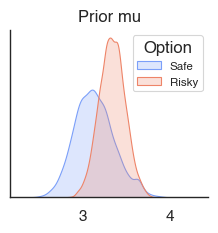

In [31]:
palette = sns.color_palette('coolwarm', 4)
palette = [palette[ix] for ix in [0, 3]]

df_prior_mu = pd.concat((idata.posterior['risky_prior_mu_mu'].to_dataframe(), (idata.posterior['safe_prior_mu_mu'].to_dataframe())), axis=1)
df_prior_mu.columns.name = 'parameter'
df_prior_mu = df_prior_mu.stack().to_frame('value')
df_prior_mu['Option'] = df_prior_mu.index.get_level_values('parameter').map({'risky_prior_mu_mu':'Risky', 'safe_prior_mu_mu':'Safe'})

df_prior_mu['value_norm_scale'] = np.exp(df_prior_mu['value'])

x = 'value' # 'value_norm_scale' #
fac = sns.FacetGrid(df_prior_mu.reset_index(), hue='Option', palette=palette, aspect=1.1, height=2.5, hue_order=['Safe', 'Risky'])
fac.map(sns.kdeplot, x, fill=True)
fac.set(xlabel=None, ylabel=None, yticks=[])
plt.title('Prior mu')
plt.legend(title='Option', loc='upper right',fontsize='x-small')

#plt.savefig(op.join(plot_folder_path, 'NLC_model-6_prior_mu.pdf'), bbox_inches='tight')

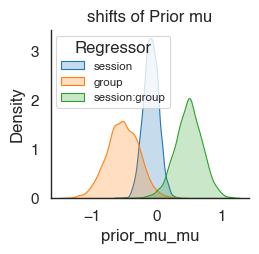

In [27]:
df_prior_mu = idata.posterior['prior_mu_mu'].to_dataframe()

#df_prior_mu.xs('group',0,'prior_mu_regressors') .xs('session:group',0,'prior_mu_regressors')
fac = sns.FacetGrid(df_prior_mu.reset_index(),hue='prior_mu_regressors',  aspect=1.1, height=2.5) #hue='prior_mu_regressors', palette=palette,
fac.map(sns.kdeplot, 'prior_mu_mu', fill=True)
plt.legend(title='Regressor', loc='upper left',fontsize='x-small')
plt.title('shifts of Prior mu')

plt.savefig(op.join(plot_folder_path, 'NLC_model-6_prior_mu_regressors.pdf'), bbox_inches='tight')